# 2. Construcción de teselas batimétricas

- Se realiza la partición de las mallas batimétricas interpoladas en **teselas regulares** de tamaño fijo. 
- Para X6By5 se utilizan teselas de 68 x 68 píxeles.
- Se hace la partición de los datos en teselas para reducir la dimensionalidad de los datos de entrada

## 2.1. Pasos

- Se trabaja sobre una **malla regular base** previamente generada para el sector.
- Cada batimetría interpolada se divide en teselas de tamaño `TILE_SIZE × TILE_SIZE`.
- Para cada tesela se calcula:
  - número de celdas válidas,
  - número de `NaN`,
  - cobertura porcentual.
- Se descartan las teselas con menos del **10 % de celdas válidas**.
- Los `NaN` de las teselas aceptadas se reemplazan por **0.0**.
- Se guardan dos salidas:
  - un archivo `.npz` con el tensor `X_tiles`,
  - un archivo `.csv` con los metadatos de las teselas aceptadas.

```python
nrows, ncols = gx.shape

n_tiles_filas = nrows // TILE_SIZE
n_tiles_cols = ncols // TILE_SIZE

# Guardar índices de cada tesela completa
tiles_idx = []

for i in range(n_tiles_filas):
    for j in range(n_tiles_cols):
        r0 = i * TILE_SIZE
        r1 = r0 + TILE_SIZE
        c0 = j * TILE_SIZE
        c1 = c0 + TILE_SIZE

        tiles_idx.append({
            "tile_id": f"r{r0:04d}_c{c0:04d}",
            "i_tile": i,
            "j_tile": j,
            "row_ini": r0,
            "row_fin": r1,
            "col_ini": c0,
            "col_fin": c1
        })


df_tiles_idx = pd.DataFrame(tiles_idx)


Tamaño de la malla: 494 x 68
Tamaño de tesela: 68 x 68
Teselas completas en filas: 7
Teselas completas en columnas: 1
Filas sobrantes: 18
Columnas sobrantes: 0


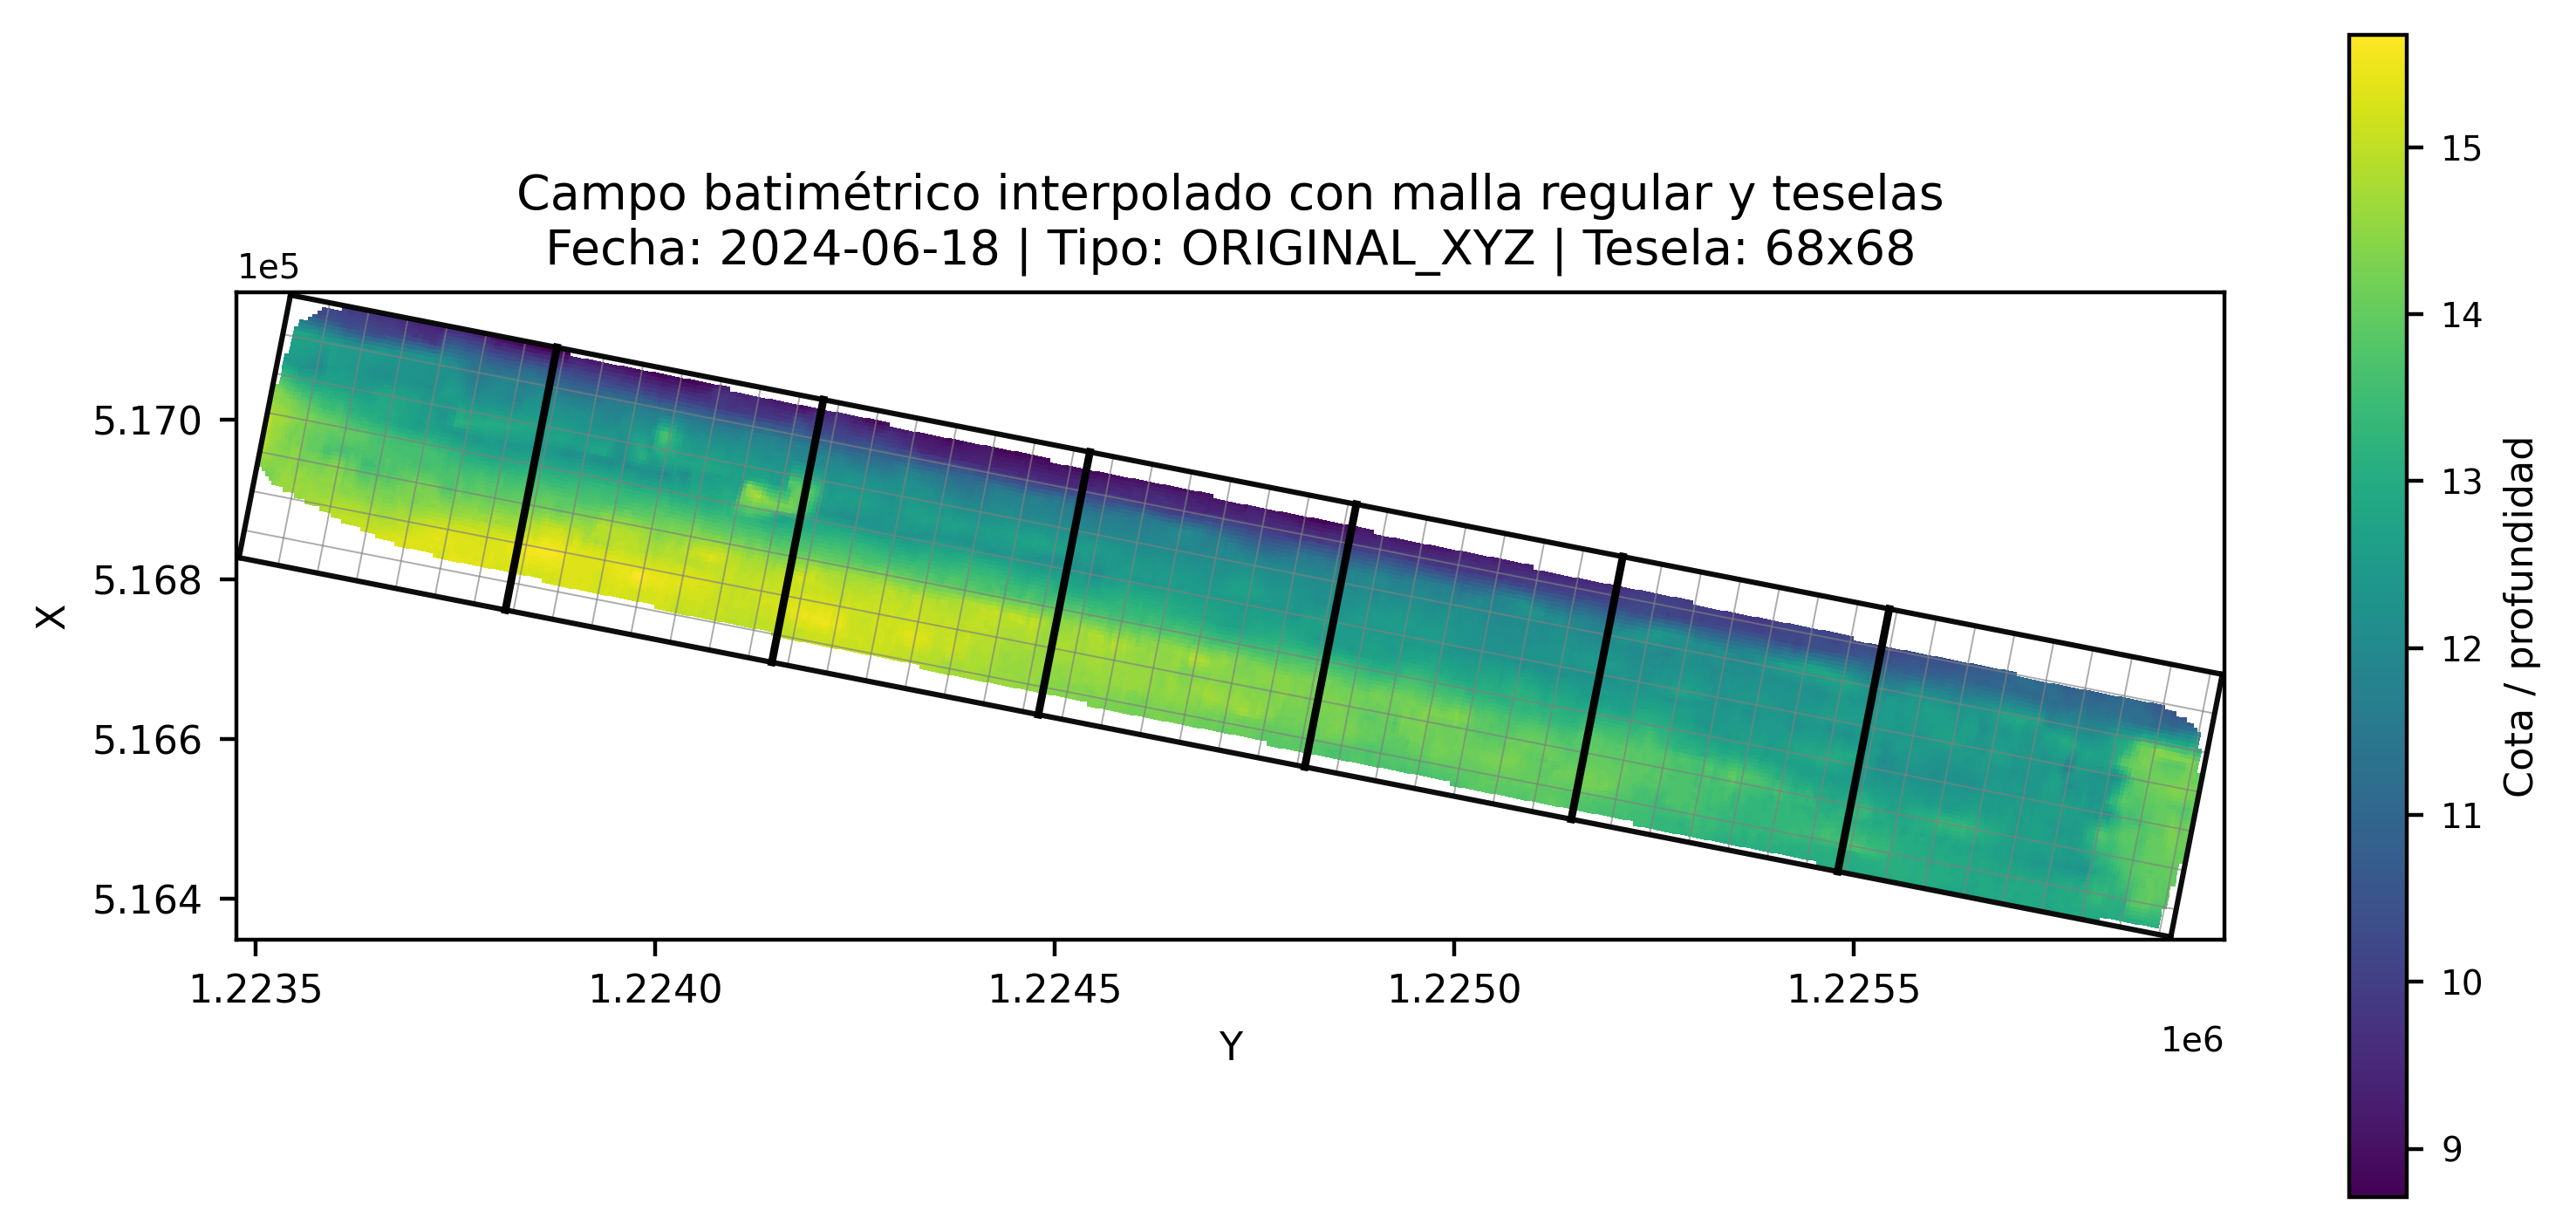

Figura guardada en:
C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\jbook_LSMTConv\docs\images\campo_interpolado_malla_y_teselas.png


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. PARÁMETROS
SECTOR = "X6By5"
GRID_STEP_PLOT = 10   # malla regular fina
TILE_SIZE = 68        # tamaño de tesela completa

plt.rcParams["figure.dpi"] = 400

ruta_grid_base = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\X6By5\1_MallasInterpoladas_X6By5\grid_base_X6By5_5m.npz"
ruta_npz_interpolado = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\X6By5\1_MallasInterpoladas_X6By5\batimetria_interpolada_X6By5_20240618.npz"

carpeta_salida = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\jbook_LSMTConv\docs\images"
os.makedirs(carpeta_salida, exist_ok=True)

nombre_figura = "campo_interpolado_malla_y_teselas.png"

# 2. LEER NPZ DE MALLA BASE
grid_data = np.load(ruta_grid_base)

gx = grid_data["gx"]
gy = grid_data["gy"]
mask_grid = grid_data["mask_grid"]
centroide = grid_data["centroide"]
u = grid_data["u"]
v = grid_data["v"]

X_real = centroide[0] + gx * v[0] + gy * u[0]
Y_real = centroide[1] + gx * v[1] + gy * u[1]

# 3. LEER CAMPO INTERPOLADO
campo_data = np.load(ruta_npz_interpolado)
z_grid = campo_data["z_grid"]

fecha = campo_data["fecha"][0] if "fecha" in campo_data else "sin_fecha"
source_type = campo_data["source_type"][0] if "source_type" in campo_data else "NA"

# 4. DIMENSIONES
nrows, ncols = z_grid.shape

n_tiles_filas = nrows // TILE_SIZE
n_tiles_cols = ncols // TILE_SIZE
sobrante_filas = nrows % TILE_SIZE
sobrante_cols = ncols % TILE_SIZE

print(f"Tamaño de la malla: {nrows} x {ncols}")
print(f"Tamaño de tesela: {TILE_SIZE} x {TILE_SIZE}")
print(f"Teselas completas en filas: {n_tiles_filas}")
print(f"Teselas completas en columnas: {n_tiles_cols}")
print(f"Filas sobrantes: {sobrante_filas}")
print(f"Columnas sobrantes: {sobrante_cols}")

# 5. GRAFICAR
fig, ax = plt.subplots(figsize=(8, 4), dpi=400)

# Campo interpolado rotado
pcm = ax.pcolormesh(
    Y_real,
    X_real,
    z_grid,
    shading="auto"
)

# --------------------------------------------------
# MALLA REGULAR COMPLETA (gris, fina)
# --------------------------------------------------

# Líneas horizontales de la malla
for i in range(0, nrows, GRID_STEP_PLOT):
    ax.plot(
        Y_real[i, :],
        X_real[i, :],
        color="gray",
        linewidth=0.35,
        alpha=0.65,
        zorder=2
    )

# Líneas verticales de la malla
for j in range(0, ncols, GRID_STEP_PLOT):
    ax.plot(
        Y_real[:, j],
        X_real[:, j],
        color="gray",
        linewidth=0.35,
        alpha=0.65,
        zorder=2
    )

# --------------------------------------------------
# BORDES EXTERNOS DEL DOMINIO (negro)
# --------------------------------------------------
ax.plot(Y_real[0, :],  X_real[0, :],  color="black", linewidth=1.1, alpha=0.95, zorder=3)
ax.plot(Y_real[-1, :], X_real[-1, :], color="black", linewidth=1.1, alpha=0.95, zorder=3)
ax.plot(Y_real[:, 0],  X_real[:, 0],  color="black", linewidth=1.1, alpha=0.95, zorder=3)
ax.plot(Y_real[:, -1], X_real[:, -1], color="black", linewidth=1.1, alpha=0.95, zorder=3)

# --------------------------------------------------
# PARTICIÓN DE TESELAS COMPLETAS (negro, más grueso)
# OJO: solo fronteras internas entre teselas completas.
# No se dibuja una línea extra para separar el sobrante final.
# --------------------------------------------------

# Fronteras horizontales internas entre teselas completas
for i in range(TILE_SIZE, n_tiles_filas * TILE_SIZE, TILE_SIZE):
    ax.plot(
        Y_real[i, :],
        X_real[i, :],
        color="black",
        linewidth=1.6,
        alpha=0.98,
        zorder=4
    )

# Fronteras verticales internas entre teselas completas
for j in range(TILE_SIZE, n_tiles_cols * TILE_SIZE, TILE_SIZE):
    ax.plot(
        Y_real[:, j],
        X_real[:, j],
        color="black",
        linewidth=1.6,
        alpha=0.98,
        zorder=4
    )

# 6. FORMATO
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
ax.xaxis.get_offset_text().set_size(7)
ax.yaxis.get_offset_text().set_size(7)

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.set_label("Cota / profundidad", fontsize=8)
cbar.ax.tick_params(labelsize=7)

ax.set_title(
    f"Campo batimétrico interpolado con malla regular y teselas\n"
    f"Fecha: {fecha} | Tipo: {source_type} | Tesela: {TILE_SIZE}x{TILE_SIZE}",
    fontsize=10
)
ax.set_xlabel("Y", fontsize=8)
ax.set_ylabel("X", fontsize=8)
ax.tick_params(axis="both", labelsize=8)
ax.set_aspect("equal")

plt.tight_layout()

# 7. GUARDAR
ruta_guardado = os.path.join(carpeta_salida, nombre_figura)
plt.savefig(ruta_guardado, dpi=400, bbox_inches="tight")
plt.show()

print(f"Figura guardada en:\n{ruta_guardado}")

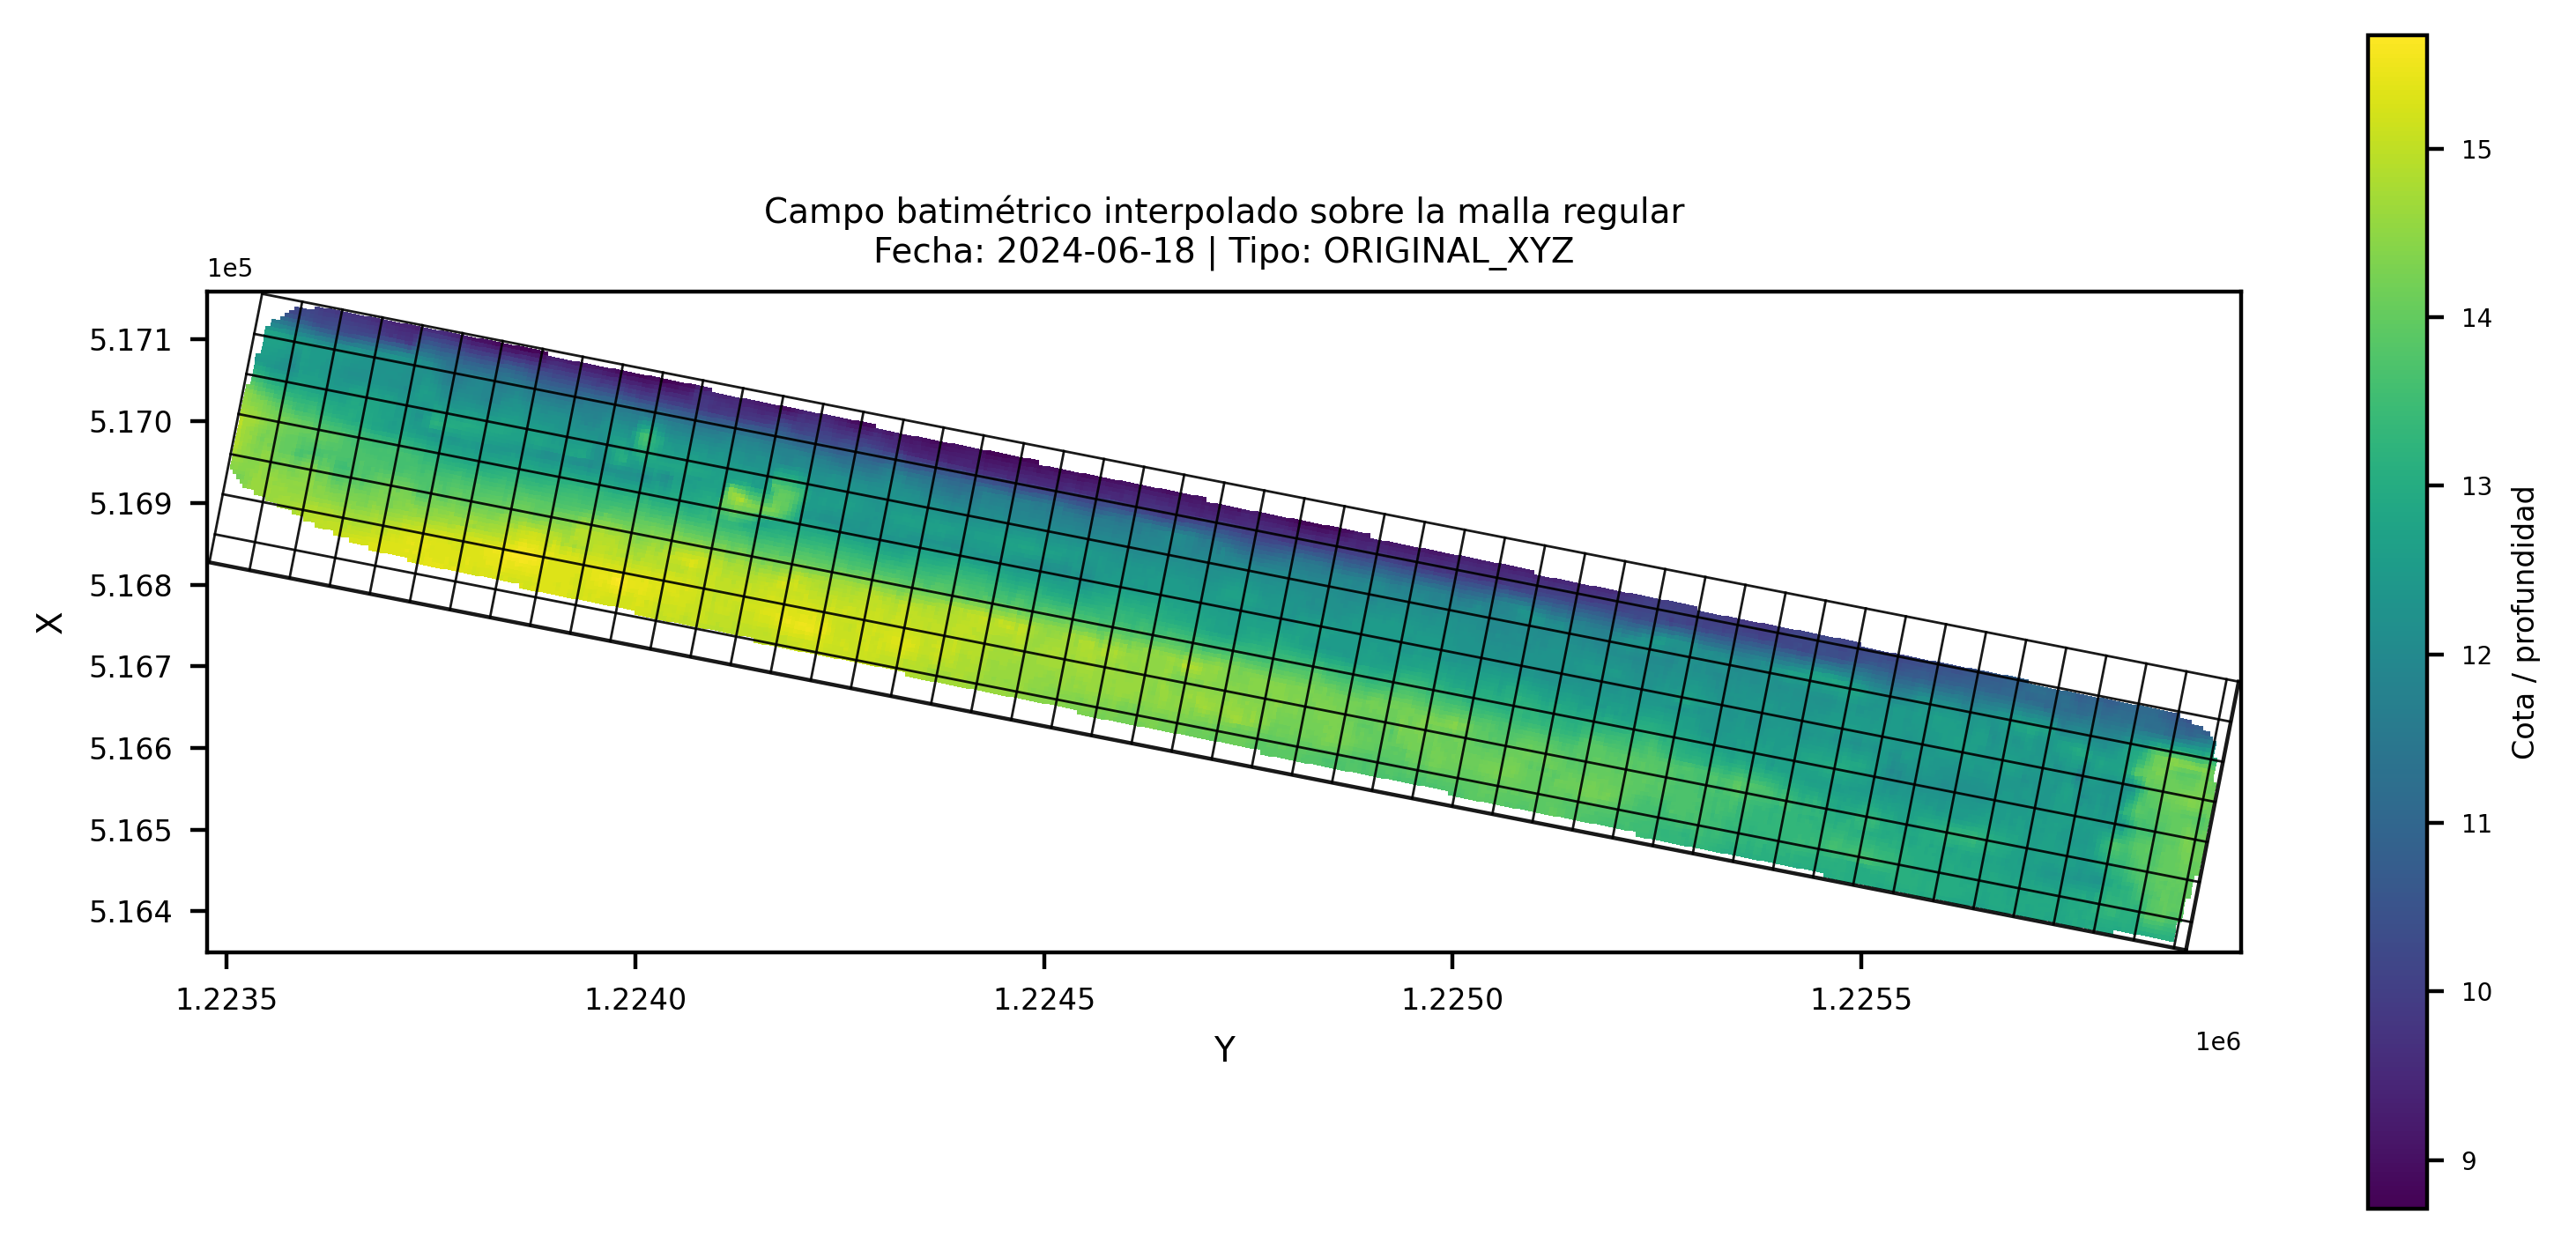